In [1]:
import os
import tarfile
import gzip
import shutil
from pathlib import Path

import pandas as pd
import scanpy as sc
import anndata as ad
from scipy.io import mmread

os.chdir('c:\\Users\\ankit\\Documents\\scFM\\train_data\\GSE189600') 

In [2]:
# ----------------------------
# USER SETTINGS
# ----------------------------
raw_tar = "GSE189600_RAW.tar"         # path to downloaded GEO raw tar
extract_dir = "GSE189600_raw_extracted"
output_h5ad = "GSE189600_human_snRNA_raw.h5ad"

# Human liver snRNA-seq samples from GEO
human_samples = {
    "GSM6808755": "human_healthy_rep1",
    "GSM6808756": "human_healthy_rep2",
    "GSM6808757": "human_healthy_rep3",
    "GSM6808758": "human_NASH_rep1",
    "GSM6808759": "human_NASH_rep2",
    "GSM6808760": "human_NASH_rep3",
}

# ----------------------------
# HELPERS
# ----------------------------
def safe_extract_tar(tar_path, out_dir):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    with tarfile.open(tar_path, "r") as tar:
        tar.extractall(path=out_dir)

def gunzip_if_needed(path):
    """
    If file ends with .gz, unzip it once and return unzipped path.
    Otherwise return original path.
    """
    path = Path(path)
    if path.suffix != ".gz":
        return path

    unzipped = path.with_suffix("")  # remove .gz
    if not unzipped.exists():
        with gzip.open(path, "rb") as f_in, open(unzipped, "wb") as f_out:
            shutil.copyfileobj(f_in, f_out)
    return unzipped

def find_sample_files(sample_id, search_dir):
    """
    Tries to identify matrix/barcodes/features for a given GSM sample
    by searching filenames that contain the sample_id.
    """
    search_dir = Path(search_dir)
    all_files = list(search_dir.rglob("*"))

    sample_files = [f for f in all_files if sample_id in f.name or sample_id in str(f)]
    sample_files = [f for f in sample_files if f.is_file()]

    matrix_file = None
    barcodes_file = None
    features_file = None

    for f in sample_files:
        name = f.name.lower()
        if "matrix" in name and (name.endswith(".mtx") or name.endswith(".mtx.gz")):
            matrix_file = f
        elif "barcode" in name and (name.endswith(".tsv") or name.endswith(".tsv.gz") or name.endswith(".txt") or name.endswith(".txt.gz")):
            barcodes_file = f
        elif ("feature" in name or "gene" in name or "peak" in name) and (
            name.endswith(".tsv") or name.endswith(".tsv.gz") or name.endswith(".txt") or name.endswith(".txt.gz")
        ):
            features_file = f

    return matrix_file, barcodes_file, features_file, sample_files

def read_10x_like_mtx(matrix_file, barcodes_file, features_file, sample_id, sample_label):
    """
    Reads a 10x-style matrix and returns AnnData with cells x genes.
    """
    matrix_file = gunzip_if_needed(matrix_file)
    barcodes_file = gunzip_if_needed(barcodes_file)
    features_file = gunzip_if_needed(features_file)

    # Read matrix
    X = mmread(matrix_file).tocsr().T  # transpose so rows=cells, cols=features

    # Read barcodes
    barcodes = pd.read_csv(barcodes_file, header=None, sep="\t")
    barcodes = barcodes.iloc[:, 0].astype(str).tolist()

    # Read features
    features = pd.read_csv(features_file, header=None, sep="\t")

    # Handle common 10x feature formats
    # Usually:
    # col0 = gene_id
    # col1 = gene_symbol
    # col2 = feature_type
    if features.shape[1] >= 2:
        gene_ids = features.iloc[:, 0].astype(str).tolist()
        gene_names = features.iloc[:, 1].astype(str).tolist()
    else:
        gene_ids = features.iloc[:, 0].astype(str).tolist()
        gene_names = features.iloc[:, 0].astype(str).tolist()

    adata = ad.AnnData(X=X)
    adata.obs_names = [f"{sample_id}_{bc}" for bc in barcodes]
    adata.var_names = pd.Index(gene_names).astype(str)
    adata.var["gene_ids"] = gene_ids
    adata.var["gene_symbols"] = gene_names

    # Make var_names unique if needed
    adata.var_names_make_unique()

    # Add sample metadata
    adata.obs["sample_id"] = sample_id
    adata.obs["sample_name"] = sample_label
    adata.obs["condition"] = "healthy" if "healthy" in sample_label.lower() else "NASH"
    adata.obs["species"] = "Homo sapiens"
    adata.obs["assay"] = "snRNA-seq"
    adata.obs["dataset"] = "GSE189600"

    return adata



In [4]:
# ----------------------------
# MAIN
# ----------------------------
print("Extracting raw tar...")
safe_extract_tar(raw_tar, extract_dir)

adatas = []

for gsm, label in human_samples.items():
    print(f"\nSearching files for {gsm} ({label})")
    matrix_file, barcodes_file, features_file, matched = find_sample_files(gsm, extract_dir)

    if matrix_file is None or barcodes_file is None or features_file is None:
        print(f"Could not automatically detect all files for {gsm}.")
        print("Matched files:")
        for f in matched:
            print("  ", f)
        raise FileNotFoundError(
            f"Missing matrix/barcodes/features for {gsm}. "
            "Inspect the matched files above and adjust the file matching logic if needed."
        )

    print("  matrix  :", matrix_file)
    print("  barcodes:", barcodes_file)
    print("  features:", features_file)

    adata_i = read_10x_like_mtx(
        matrix_file=matrix_file,
        barcodes_file=barcodes_file,
        features_file=features_file,
        sample_id=gsm,
        sample_label=label
    )

    print(f"  shape: {adata_i.shape}")
    adatas.append(adata_i)

print("\nMerging human samples...")
adata = ad.concat(
    adatas,
    axis=0,
    join="outer",
    label="batch",
    keys=[a.obs['sample_id'].iloc[0] for a in adatas],
    merge="same"
)

# Store raw counts
adata.layers["counts"] = adata.X.copy()

print("\nFinal merged object:")
print(adata)



Extracting raw tar...

Searching files for GSM6808755 (human_healthy_rep1)
  matrix  : GSE189600_raw_extracted\GSM6808755_Y21822A1_matrix.mtx.gz
  barcodes: GSE189600_raw_extracted\GSM6808755_Y21822A1_barcodes.tsv.gz
  features: GSE189600_raw_extracted\GSM6808755_Y21822A1_features.tsv.gz
  shape: (9779, 36601)

Searching files for GSM6808756 (human_healthy_rep2)
  matrix  : GSE189600_raw_extracted\GSM6808756_Y31122A5_matrix.mtx.gz
  barcodes: GSE189600_raw_extracted\GSM6808756_Y31122A5_barcodes.tsv.gz
  features: GSE189600_raw_extracted\GSM6808756_Y31122A5_features.tsv.gz
  shape: (12260, 36601)

Searching files for GSM6808757 (human_healthy_rep3)
  matrix  : GSE189600_raw_extracted\GSM6808757_Y31122A8_matrix.mtx.gz
  barcodes: GSE189600_raw_extracted\GSM6808757_Y31122A8_barcodes.tsv.gz
  features: GSE189600_raw_extracted\GSM6808757_Y31122A8_features.tsv.gz
  shape: (5593, 36601)

Searching files for GSM6808758 (human_NASH_rep1)
  matrix  : GSE189600_raw_extracted\GSM6808758_Y21822A2_m

In [10]:
print(f"\nWriting {output_h5ad} ...")
adata.write_h5ad(output_h5ad)

print("Done.")


Writing GSE189600_human_snRNA_raw.h5ad ...
Done.


In [2]:
# Read in saved h5ad to verify
output_h5ad = "GSE189600_human_snRNA_raw.h5ad"
adata = sc.read_h5ad(output_h5ad)
print(adata)

AnnData object with n_obs × n_vars = 65879 × 36601
    obs: 'sample_id', 'sample_name', 'condition', 'species', 'assay', 'dataset', 'batch', 'sex', 'age', 'ethnicity', 'Cause_of_death', 'alcohol_use'
    var: 'gene_ids', 'gene_symbols'
    layers: 'counts'


In [4]:
# View the unique values of sample_id 
print("\nUnique sample_id values:", adata.obs["sample_id"].unique())



Unique sample_id values: ['GSM6808755', 'GSM6808756', 'GSM6808757', 'GSM6808758', 'GSM6808759', 'GSM6808760']
Categories (6, object): ['GSM6808755', 'GSM6808756', 'GSM6808757', 'GSM6808758', 'GSM6808759', 'GSM6808760']


In [8]:
# Read in additional_meta.csv
additional_meta_path = "additional_meta.csv"
additional_meta = pd.read_csv(additional_meta_path)
print("\nAdditional metadata:")
print(additional_meta.head())


Additional metadata:
    sample_id sex  age                  ethnicity  \
0  GSM6808755   M   50                        NaN   
1  GSM6808756   M   50                        NaN   
2  GSM6808757   F   47                        NaN   
3  GSM6808758   M   49  Asian or Pacific Islander   
4  GSM6808759   F   64                  Caucasian   

                   Cause_of_death alcohol_use  
0  Intracerebral brain hemorrhage         NaN  
1  Intracerebral brain hemorrhage         NaN  
2                          Anoxia         NaN  
3                             NaN          No  
4                             NaN          No  


In [9]:
# Add in metadata to adata.obs by merging on sample_id
adata.obs = adata.obs.merge(additional_meta, on="sample_id", how="left")
print("\nadata.obs after merging additional metadata:")
print(adata.obs.head())


adata.obs after merging additional metadata:
    sample_id         sample_name condition       species      assay  \
0  GSM6808755  human_healthy_rep1   healthy  Homo sapiens  snRNA-seq   
1  GSM6808755  human_healthy_rep1   healthy  Homo sapiens  snRNA-seq   
2  GSM6808755  human_healthy_rep1   healthy  Homo sapiens  snRNA-seq   
3  GSM6808755  human_healthy_rep1   healthy  Homo sapiens  snRNA-seq   
4  GSM6808755  human_healthy_rep1   healthy  Homo sapiens  snRNA-seq   

     dataset       batch sex  age ethnicity                  Cause_of_death  \
0  GSE189600  GSM6808755   M   50       NaN  Intracerebral brain hemorrhage   
1  GSE189600  GSM6808755   M   50       NaN  Intracerebral brain hemorrhage   
2  GSE189600  GSM6808755   M   50       NaN  Intracerebral brain hemorrhage   
3  GSE189600  GSM6808755   M   50       NaN  Intracerebral brain hemorrhage   
4  GSE189600  GSM6808755   M   50       NaN  Intracerebral brain hemorrhage   

  alcohol_use  
0         NaN  
1         NaN 

c:\Users\ankit\miniconda3\envs\scanpy\Lib\functools.py:982: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [8]:
# View sample of adata transcriptomic data
print(adata.X[:100, :100])

# View assay type column head
print(adata.obs['assay_type'].head())

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 0 stored elements and shape (100, 100)>
AAACCCAAGAAACACT-1    scRNA-seq
AAACCCAAGAAACCAT-1    scRNA-seq
AAACCCAAGAAACCCA-1    scRNA-seq
AAACCCAAGAAACCCG-1    scRNA-seq
AAACCCAAGAAACCTG-1    scRNA-seq
Name: assay_type, dtype: category
Categories (1, object): ['scRNA-seq']


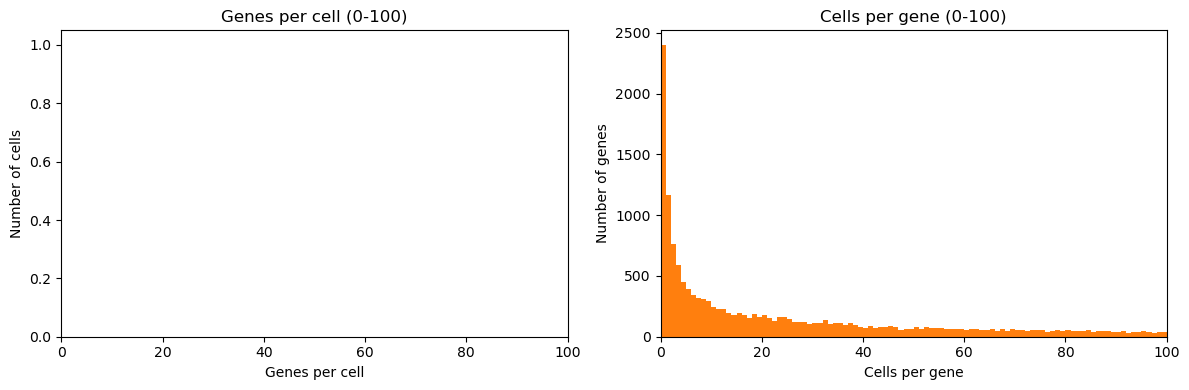

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse

X = adata.X

if sparse.issparse(X):
    X = X.tocsc()
    genes_per_cell = np.asarray((X > 0).sum(axis=1)).ravel()
    cells_per_gene = np.asarray((X > 0).sum(axis=0)).ravel()
else:
    genes_per_cell = np.sum(X > 0, axis=1)
    cells_per_gene = np.sum(X > 0, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(genes_per_cell, bins=np.arange(0, 102), color="C0", range=(0, 100))
axes[0].set_xlim(0, 100)
axes[0].set_xlabel("Genes per cell")
axes[0].set_ylabel("Number of cells")
axes[0].set_title("Genes per cell (0-100)")

axes[1].hist(cells_per_gene, bins=np.arange(0, 102), range=(0, 100), color="C1")
axes[1].set_xlim(0, 100)
axes[1].set_xlabel("Cells per gene")
axes[1].set_ylabel("Number of genes")
axes[1].set_title("Cells per gene (0-100)")

plt.tight_layout()
plt.show()

In [10]:
# Determine the minimum and maximum number of genes per cell
min_genes_per_cell = np.min(genes_per_cell)
print(f"Minimum number of genes per cell: {min_genes_per_cell}")
# Determine how many cells have at least the minimum number of genes
num_cells_with_min_genes = np.sum(genes_per_cell >= min_genes_per_cell)
print(f"Number of cells with at least {min_genes_per_cell} genes: {num_cells_with_min_genes}")

Minimum number of genes per cell: 101
Number of cells with at least 101 genes: 65879
